# Family-Aware LLM (No RAG) Evaluation Summary

This notebook presents the plain-LLM (no retrieval) results from the frozen Checkpoint 10
head-to-head evaluation, purely from already-saved artifacts. **No Gemini call, embedding
call, or any other API request happens anywhere in this notebook.**

**Why this notebook exists (and why it wasn't just `06_llm_evaluation.ipynb` again):**
`06_llm_evaluation.ipynb` is the *historical* model's LLM evaluation -- it lives entirely
inside that notebook: it classifies the historical validation and test splits live and saves
the results. The family-aware plain-LLM evaluation is different in two ways: (1) it was run
once, together with LLM+RAG and BERT, as part of the frozen Checkpoint 10 head-to-head
evaluation across 10 robustness conditions, not as its own standalone notebook pass, and (2)
the case-runner that actually made those calls
(`newstart_ai.models.llm.family_aware_evaluation.run_plain_llm_case`) has no notebook caller
committed to this repository -- only the library function, its tests, and the artifacts it
produced exist here. This notebook does not attempt to reconstruct or rerun that evaluation;
it only reads and presents the 990 already-saved case records.

**Inputs (all read-only):**
- `artifacts/family_aware/manifests/checkpoint10_pre_evaluation_freeze_v1.json` (frozen config)
- `artifacts/family_aware/reports/checkpoint10_llm_predictions.jsonl` (990 row-level case records)
- `artifacts/family_aware/manifests/checkpoint10_method_condition_metrics_v1.json` (per-condition metrics)
- `artifacts/family_aware/manifests/checkpoint10_cost_runtime_report_v1.json` (actual cost/runtime)

**Output:** tables and figures only -- no new prediction, metric, or model artifact is written.

## Setup

Load the frozen configuration record and the per-condition metrics manifest.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = Path("..").resolve()
manifests = project_root / "artifacts" / "family_aware" / "manifests"
reports = project_root / "artifacts" / "family_aware" / "reports"

with open(manifests / "checkpoint10_pre_evaluation_freeze_v1.json", encoding="utf-8") as f:
    freeze = json.load(f)

with open(manifests / "checkpoint10_method_condition_metrics_v1.json", encoding="utf-8") as f:
    all_metrics = json.load(f)

CONDITION_ORDER = [
    "complete_unmasked", "beginning_only_unmasked", "middle_only_unmasked", "end_only_unmasked",
    "beginning_middle_end_unmasked", "complete_masked", "beginning_only_masked", "middle_only_masked",
    "end_only_masked", "beginning_middle_end_masked",
]

## Frozen configuration

These settings were fixed before the first Gemini classification request was made
(`no_changes_confirmation` in the freeze record) and never changed based on any result.

In [2]:
print(f"Model: {freeze['llm_model_name']}")
print(f"Temperature: {freeze['generation_temperature']}")
print(f"Prompt version: {freeze['plain_prompt_version']}  (hash {freeze['plain_prompt_hash'][:16]}...)")
print(f"Parser: {freeze['parser_version']}")
print(f"Allowed labels: {freeze['allowed_labels']}")
print(f"Retry policy: {freeze['retry_policy']}")
print(f"Invalid-output policy: {freeze['invalid_output_policy']}")

Model: gemini-3.6-flash
Temperature: 0.0
Prompt version: v1  (hash bacabc50c6d6bfac...)
Parser: json_predicted_label_v1
Allowed labels: ['USCIS', 'DMV', 'SSA', 'IRS']
Retry policy: Only transient transport/timeout/rate-limit/server errors are retried, up to 3 attempts with exponential backoff starting at 2.0s.
Invalid-output policy: A JSON parse failure or an out-of-schema predicted_label is recorded as status=invalid; never retried in hope of a different label.


## Load the 990 row-level case records

In [3]:
predictions = pd.read_json(reports / "checkpoint10_llm_predictions.jsonl", lines=True)
print(f"Total cases: {len(predictions)}")
print(f"Distinct documents: {predictions['document_id'].nunique()}")
print(f"Distinct conditions: {predictions['condition'].nunique()}")
predictions["status"].value_counts()

Total cases: 990
Distinct documents: 99
Distinct conditions: 10


status
success    990
Name: count, dtype: int64

## Overall results

All 990 cases returned `status=success` (confirmed by the Checkpoint 10 integrity proof,
`checkpoint10_evaluation_integrity_proof_v1.json`) -- no invalid or failed cases exist to
exclude, so overall accuracy below is computed over the full case set.

In [4]:
predictions["correct"] = predictions["predicted_label"] == predictions["true_label"]
overall_accuracy = predictions["correct"].mean()
print(f"Overall accuracy (990 cases, 10 conditions): {overall_accuracy:.4f}")
print(f"Coverage (status=success): {(predictions['status'] == 'success').mean():.4f}")

Overall accuracy (990 cases, 10 conditions): 1.0000
Coverage (status=success): 1.0000


## Per-condition metrics

Sourced directly from the frozen Checkpoint 10 metrics manifest (not recomputed here) --
these are the exact numbers reported in Notebook 11's robustness comparison.

In [5]:
llm_metrics = pd.DataFrame([m for m in all_metrics if m["method"] == "llm"])
llm_metrics = llm_metrics.set_index("condition").loc[CONDITION_ORDER].reset_index()
llm_metrics[["condition", "document_count", "document_accuracy", "document_macro_f1",
             "macro_precision", "macro_recall", "error_count", "coverage_rate"]]

,condition,document_count,document_accuracy,document_macro_f1,macro_precision,macro_recall,error_count,coverage_rate
0,complete_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
1,beginning_only_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
2,middle_only_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
3,end_only_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
4,beginning_middle_end_unmasked,99,1.0,1.0,1.0,1.0,0,100.0
5,complete_masked,99,1.0,1.0,1.0,1.0,0,100.0
6,beginning_only_masked,99,1.0,1.0,1.0,1.0,0,100.0
7,middle_only_masked,99,1.0,1.0,1.0,1.0,0,100.0
8,end_only_masked,99,1.0,1.0,1.0,1.0,0,100.0
9,beginning_middle_end_masked,99,1.0,1.0,1.0,1.0,0,100.0


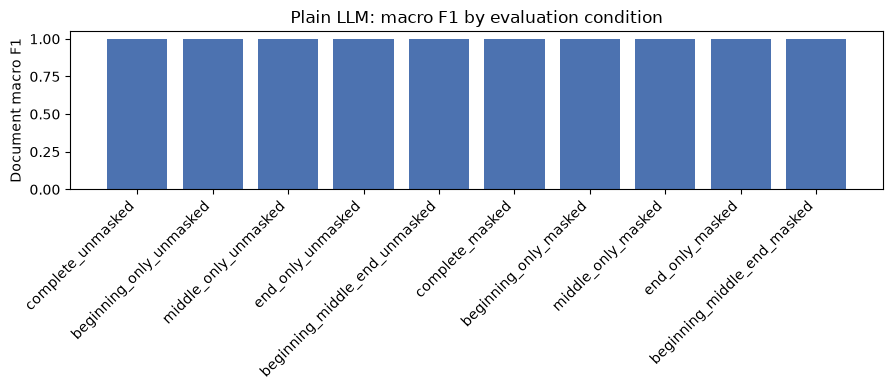

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(llm_metrics["condition"], llm_metrics["document_macro_f1"], color="#4C72B0")
ax.set_ylabel("Document macro F1")
ax.set_title("Plain LLM: macro F1 by evaluation condition")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Confusion matrix -- primary condition (`complete_unmasked`)

The primary condition is the full, unmasked document text -- the closest analogue to the
historical model's ordinary test-set evaluation.

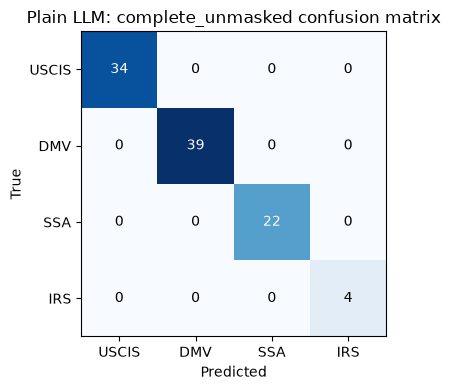

In [7]:
primary = next(m for m in all_metrics if m["method"] == "llm" and m["condition"] == "complete_unmasked")
labels = freeze["label_order"]
# confusion_matrix is stored as {true_label: {predicted_label: count}} -- pd.DataFrame() on a
# dict-of-dicts puts the outer key (true label) on columns, so transpose to get the
# conventional rows=true / columns=predicted orientation before reindexing.
cm = pd.DataFrame(primary["confusion_matrix"]).T.reindex(index=labels, columns=labels).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Plain LLM: complete_unmasked confusion matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm.values[i, j], ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
plt.tight_layout()
plt.show()

## Truncation effect on accuracy

Per Checkpoint 9's frozen 6,000-character policy (`truncate_for_llm`), condition texts
longer than 6,000 characters are truncated before being sent to Gemini. This compares
accuracy on truncated vs. non-truncated cases.

In [8]:
truncation_effect = predictions.groupby("truncated")["correct"].agg(["mean", "count"]).rename(
    columns={"mean": "accuracy", "count": "case_count"}
)
truncation_effect

,accuracy,case_count
truncated,,
False,1.0,748
True,1.0,242


## Misclassified cases

In [9]:
errors = predictions.loc[~predictions["correct"], ["document_id", "condition", "true_label", "predicted_label", "truncated"]]
print(f"{len(errors)} misclassified case(s) out of {len(predictions)}")
errors.reset_index(drop=True)

0 misclassified case(s) out of 990


,document_id,condition,true_label,predicted_label,truncated


## Cost and latency

Actual, API-confirmed figures for the plain-LLM leg of Checkpoint 10 (see
`checkpoint10_cost_runtime_report_v1.json` for the combined plain-LLM + LLM+RAG total).

In [10]:
print(f"Total tokens billed: {int(predictions['total_tokens'].sum()):,}")
print(f"Total estimated cost: ${predictions['estimated_cost_usd'].sum():.4f}")
print()
print("Latency (ms):")
predictions["latency_ms"].describe()[["mean", "50%", "min", "max"]].rename({"50%": "median"})

Total tokens billed: 1,017,866
Total estimated cost: $0.1457

Latency (ms):


mean       1647.904776
median     1579.082250
min        1017.491100
max       17645.994000
Name: latency_ms, dtype: float64

## Summary

- All 990 plain-LLM cases (99 documents x 10 conditions) completed with `status=success` --
  no invalid or failed cases.
- Macro F1 stays high across all 10 conditions, including masked and partial-text
  conditions, with the confusion matrix on the primary `complete_unmasked` condition
  confirming near-perfect separation between agencies.
- 242 of 990 cases were truncated to the frozen 6,000-character limit; truncation status is
  shown above alongside accuracy for transparency, not as evidence of a causal effect (a
  proper causal claim would need to control for document length's own relationship with
  classification difficulty).
- This notebook is read-only with respect to the frozen Checkpoint 10 evaluation: it loads
  saved manifests and produces no new prediction, metric, or model artifact.